# 加州房价数据集：L2 正则化回归

目标：在自定义多元线性回归的基础上引入 L2 正则化惩罚，也就是岭回归。这里仍然不调用 `sklearn.linear_model.Ridge`。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 正则化思想

普通线性回归最小化残差平方和。岭回归额外加入 L2 惩罚项：

$$J(\theta)=\sum_i(y_i-\hat y_i)^2+\alpha\sum_{j=1}^{p}w_j^2$$

其中 $w_j$ 是特征系数，截距项不参与惩罚。$\alpha$ 越大，系数会被压得越小，模型更保守。

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
feature_names = list(housing.feature_names)
target_name = housing.target_names[0]

X = df[feature_names].to_numpy(dtype=float)
y = df[target_name].to_numpy(dtype=float)

print("样本数量:", X.shape[0])
print("特征数量:", X.shape[1])
display(df.head())

样本数量: 20640
特征数量: 8


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. 划分训练集、验证集和测试集

In [4]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("训练集:", X_train.shape)
print("验证集:", X_val.shape)
print("测试集:", X_test.shape)

训练集: (12384, 8)
验证集: (4128, 8)
测试集: (4128, 8)


## 3. 自己设计 L2 正则化回归类

岭回归闭式解为：

$$\theta=(X_b^TX_b+\alpha P)^+X_b^Ty$$

$P$ 是惩罚矩阵，截距位置为 0，其余对角线为 1。

In [5]:
class MyRidgeRegression:
    """
    自定义 L2 正则化多元线性回归类。

    类的运行流程：
    1. fit 中给 X 添加截距列，构造惩罚矩阵 penalty；
    2. 使用 (X_b.T @ X_b + alpha * penalty)^+ @ X_b.T @ y 求参数；
    3. penalty[0, 0] = 0，表示截距项不做正则化；
    4. predict 复用 fit 得到的 theta_ 输出预测值。

    重要变量：
    - alpha：正则化强度，是实例属性；
    - penalty：fit 内部局部变量，控制哪些参数被惩罚；
    - theta_ / coef_ / intercept_：训练后的模型参数。
    """

    def __init__(self, alpha=1.0, fit_intercept=True):
        self.alpha = float(alpha)
        self.fit_intercept = fit_intercept
        self.theta_ = None
        self.intercept_ = None
        self.coef_ = None

    def _add_intercept(self, X):
        """
        运行流程：
        1. 将输入 X 转换成二维 numpy 数组；
        2. 若需要截距，则拼接全 1 列；
        3. 返回设计矩阵 X_b。
        """
        X = np.asarray(X, dtype=float)
        if not self.fit_intercept:
            return X
        ones = np.ones((X.shape[0], 1))
        return np.c_[ones, X]

    def fit(self, X, y):
        """
        运行流程：
        1. 生成添加截距后的 X_b；
        2. 构造对角惩罚矩阵 penalty；
        3. 将 penalty[0, 0] 设为 0，避免惩罚截距；
        4. 求解岭回归闭式解并保存参数。

        依赖关系：predict 和 score 都依赖本函数保存的 theta_。
        """
        X_b = self._add_intercept(X)
        y = np.asarray(y, dtype=float)

        penalty = np.eye(X_b.shape[1])
        if self.fit_intercept:
            penalty[0, 0] = 0.0

        self.theta_ = np.linalg.pinv(X_b.T @ X_b + self.alpha * penalty) @ X_b.T @ y

        if self.fit_intercept:
            self.intercept_ = self.theta_[0]
            self.coef_ = self.theta_[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = self.theta_
        return self

    def predict(self, X):
        """
        运行流程：
        1. 检查模型是否已训练；
        2. 给输入 X 添加截距列；
        3. 计算 X_b @ theta_ 作为预测结果。
        """
        if self.theta_ is None:
            raise RuntimeError("模型尚未训练，请先调用 fit。")
        X_b = self._add_intercept(X)
        return X_b @ self.theta_

    def score(self, X, y):
        """
        运行流程：
        1. 调用 predict；
        2. 计算并返回 R^2 分数。
        """
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        sse = np.sum((y - y_pred) ** 2)
        sst = np.sum((y - np.mean(y)) ** 2)
        return 1 - sse / sst


def regression_metrics(y_true, y_pred):
    """
    运行流程：
    1. 计算真实值和预测值之间的 residual；
    2. 返回 MAE、RMSE、R^2，用于比较不同 alpha 的效果。
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residual = y_true - y_pred
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual ** 2))
    sse = np.sum(residual ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sse / sst
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

## 4. 在验证集上选择正则化强度

In [6]:
alpha_candidates = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
records = []
models = {}

for alpha in alpha_candidates:
    model = MyRidgeRegression(alpha=alpha)
    model.fit(X_train, y_train)
    models[alpha] = model

    train_metrics = regression_metrics(y_train, model.predict(X_train))
    val_metrics = regression_metrics(y_val, model.predict(X_val))
    records.append({
        "alpha": alpha,
        "train_RMSE": train_metrics["RMSE"],
        "val_RMSE": val_metrics["RMSE"],
        "train_R2": train_metrics["R2"],
        "val_R2": val_metrics["R2"],
        "coef_L2_norm": np.linalg.norm(model.coef_),
    })

validation_table = pd.DataFrame(records)
best_alpha = validation_table.loc[validation_table["val_RMSE"].idxmin(), "alpha"]

print("验证集上最优 alpha:", best_alpha)
display(validation_table.round(5))

验证集上最优 alpha: 10.0


,alpha,train_RMSE,val_RMSE,train_R2,val_R2,coef_L2_norm
0,0.01,0.71735,0.72977,0.61213,0.59201,1.59007
1,0.10,0.71735,0.72977,0.61213,0.59201,1.58996
2,1.00,0.71735,0.72976,0.61213,0.59202,1.58878
3,10.00,0.71736,0.72971,0.61212,0.59208,1.57715
4,100.00,0.71830,0.73002,0.61110,0.59173,1.47360
5,1000.00,0.74544,0.75398,0.58117,0.56449,1.00318


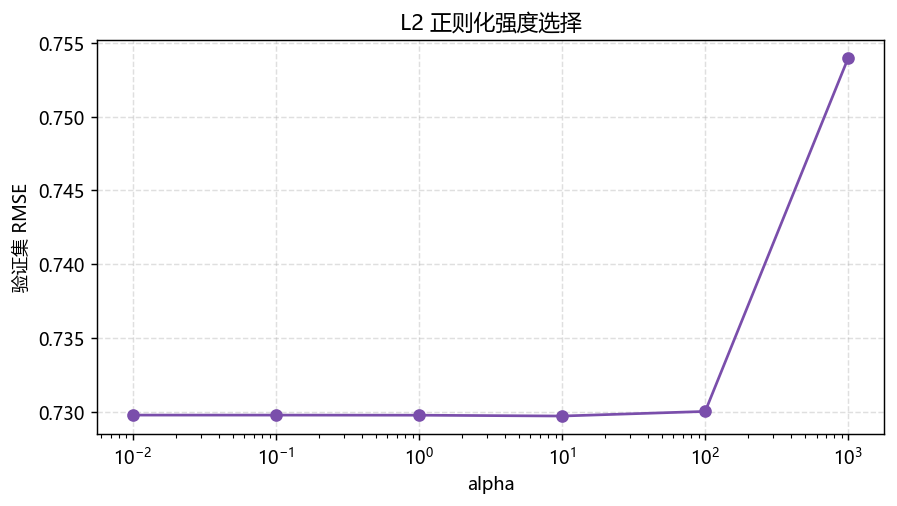

In [7]:
plt.figure(figsize=(7, 4), dpi=130)
plt.semilogx(validation_table["alpha"], validation_table["val_RMSE"], marker="o", color="#7a4eab")
plt.xlabel("alpha")
plt.ylabel("验证集 RMSE")
plt.title("L2 正则化强度选择")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 5. 使用最优 alpha 重新训练并测试

选择 `alpha` 后，把训练集和验证集合并，再重新拟合标准化器和模型。测试集不参与训练。

In [8]:
X_train_val_raw = np.vstack([X_train_raw, X_val_raw])
y_train_val = np.r_[y_train, y_val]

final_scaler = StandardScaler()
X_train_val = final_scaler.fit_transform(X_train_val_raw)
X_test_final = final_scaler.transform(X_test_raw)

ridge_model = MyRidgeRegression(alpha=best_alpha)
ridge_model.fit(X_train_val, y_train_val)

baseline_model = MyRidgeRegression(alpha=0.0)
baseline_model.fit(X_train_val, y_train_val)

ridge_test_pred = ridge_model.predict(X_test_final)
baseline_test_pred = baseline_model.predict(X_test_final)

comparison = pd.DataFrame(
    [
        regression_metrics(y_test, baseline_test_pred),
        regression_metrics(y_test, ridge_test_pred),
    ],
    index=["无正则化", f"L2 正则化 alpha={best_alpha:g}"],
)
display(comparison.round(4))

,MAE,RMSE,R2
无正则化,0.5341,0.7426,0.5978
L2 正则化 alpha=10,0.5341,0.7424,0.5980


## 6. 比较系数变化

In [9]:
coef_compare = pd.DataFrame({
    "feature": feature_names,
    "baseline_coef": baseline_model.coef_,
    "ridge_coef": ridge_model.coef_,
})
coef_compare["abs_change"] = (coef_compare["ridge_coef"] - coef_compare["baseline_coef"]).abs()
coef_compare = coef_compare.sort_values("abs_change", ascending=False)
display(coef_compare.round(5))

print("无正则化系数 L2 范数:", round(np.linalg.norm(baseline_model.coef_), 5))
print("L2 正则化系数 L2 范数:", round(np.linalg.norm(ridge_model.coef_), 5))

,feature,baseline_coef,ridge_coef,abs_change
7,Longitude,-0.86908,-0.86145,0.00764
6,Latitude,-0.89270,-0.88516,0.00755
3,AveBedrms,0.33274,0.33041,0.00233
2,AveRooms,-0.29029,-0.28849,0.00180
1,HouseAge,0.12238,0.12317,0.00079
0,MedInc,0.84048,0.84002,0.00047
4,Population,-0.00037,-0.00011,0.00027
5,AveOccup,-0.04094,-0.04097,0.00003


无正则化系数 L2 范数: 1.57171
L2 正则化系数 L2 范数: 1.5622


## 7. 输出正则化模型预测结果

In [10]:
ridge_prediction_result = pd.DataFrame({
    "actual_MedHouseVal": y_test[:12],
    "ridge_predicted_MedHouseVal": ridge_test_pred[:12],
})
ridge_prediction_result["absolute_error"] = (
    ridge_prediction_result["actual_MedHouseVal"] - ridge_prediction_result["ridge_predicted_MedHouseVal"]
).abs()
display(ridge_prediction_result.round(4))

,actual_MedHouseVal,ridge_predicted_MedHouseVal,absolute_error
0,0.413,1.9181,1.5051
1,0.690,0.7217,0.0317
2,1.675,2.3905,0.7155
3,2.359,1.8318,0.5272
4,0.584,1.2746,0.6906
5,0.882,1.5338,0.6518
6,5.000,3.3937,1.6063
7,1.221,2.0668,0.8458
8,1.525,2.1491,0.6241
9,0.944,0.7637,0.1803


## 8. 可视化正则化预测效果

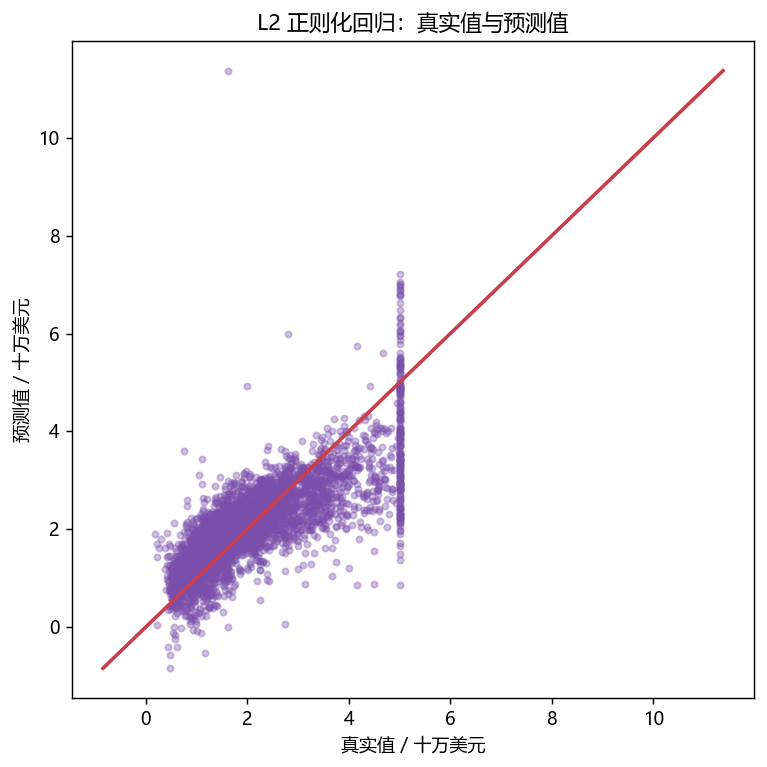

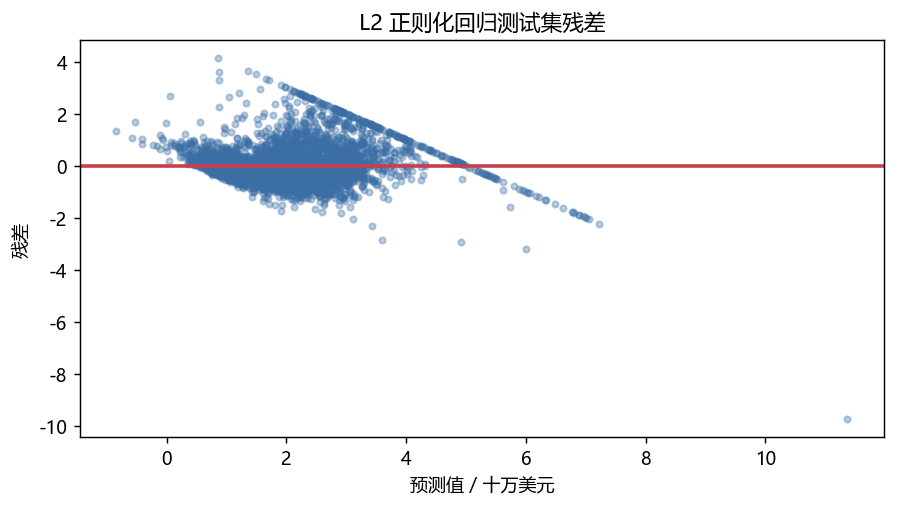

In [11]:
plt.figure(figsize=(6, 6), dpi=130)
plt.scatter(y_test, ridge_test_pred, s=12, alpha=0.35, color="#7a4eab")
low = min(y_test.min(), ridge_test_pred.min())
high = max(y_test.max(), ridge_test_pred.max())
plt.plot([low, high], [low, high], color="#c83e4d", linewidth=2)
plt.xlabel("真实值 / 十万美元")
plt.ylabel("预测值 / 十万美元")
plt.title("L2 正则化回归：真实值与预测值")
plt.tight_layout()
plt.show()

ridge_residuals = y_test - ridge_test_pred
plt.figure(figsize=(7, 4), dpi=130)
plt.scatter(ridge_test_pred, ridge_residuals, s=12, alpha=0.35, color="#3a6ea5")
plt.axhline(0, color="#c83e4d", linewidth=2)
plt.xlabel("预测值 / 十万美元")
plt.ylabel("残差")
plt.title("L2 正则化回归测试集残差")
plt.tight_layout()
plt.show()

## 9. 小结

本 notebook 在多元线性回归基础上加入 L2 正则化惩罚，完成了 alpha 选择、重新训练、测试集预测和系数压缩分析。岭回归通常不会让简单线性模型在该数据集上大幅提升，但能使系数更稳定，是处理多重共线性和抑制过拟合的常用方法。